Script to interpolate basins at different resolutions for ismip7

created by ronja.reese@northumbria.ac.uk

In [1]:
import xarray as xr

In [10]:
data_dir = '/media/NAS2/ISMIP7/share_with_modellers/'
file_name = data_dir+'imbie2/basin_numbers_ismip8km_v2.nc'

In [11]:
# Load 8km basins
basins_8km = xr.open_dataset(file_name)

In [30]:
for grid in ['1km','2km', '4km', '8km','16km', '32km', '64km' ]:
    print(grid)
    alternative_grid = xr.open_dataset('/media/NAS2/pism-ais/pism_input_data/cdo_remapgrids/ismip'+grid+'.nc')
    
    basins_other = basins_8km.interp_like(alternative_grid, method='nearest')
    basins_other.assign_attrs(description='imbie2 basins remapped from 8km to '+grid+' using nearest neighbor.')
    
    # Save as NetCDF
    basins_other.to_netcdf(data_dir+'parameterisations/imbie2/basin_numbers_ismip'+grid+'_v2.nc')


1km
2km
4km
8km
16km
32km
64km


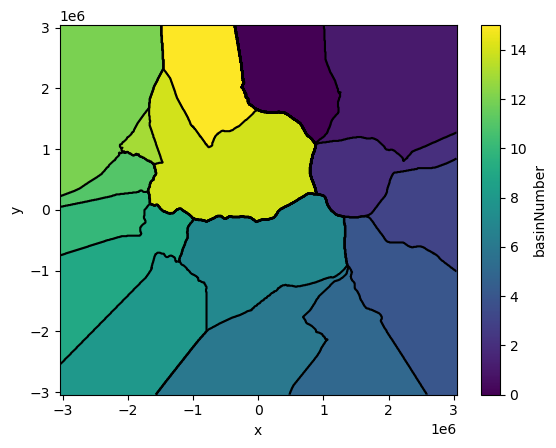

In [28]:
(basins_other).basinNumber.plot()
basins_8km.basinNumber.plot.contour(levels = np.arange(0,16), colors=['black'])